In [1]:
import string

import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import stats
from pathlib import Path
from scipy.stats import kruskal, shapiro, f_oneway
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## Data Preprocessing

In [2]:
df_base = pd.read_csv('./data/Attack-A-Results.csv')
df_base.head()

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,BIM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss
0,3V,True,True,0.014524,0.239827,0.181424,0.059129,0.074586,0.066797,0.001540,0.038697,0.010140
1,3V,True,True,0.015393,0.220886,0.165202,0.059679,0.074098,0.066235,0.000997,0.015329,0.006447
2,3V,True,True,0.014677,0.224151,0.166806,0.056570,0.071466,0.063752,0.001310,0.043454,0.008814
3,3V,True,True,0.015958,0.242514,0.182912,0.057411,0.072123,0.064612,0.001788,0.037315,0.008808
4,3V,True,True,0.015271,0.240031,0.181099,0.058963,0.074117,0.066427,0.001093,0.029084,0.008983


In [3]:
df_test = df_base.loc[
    (df_base['image_attack'] == True) &
    (df_base['sketch_attack'] == False)
].copy().reset_index(drop=True)

df_test['FGSM_IM_Abs_Increase'] = (
    df_test['FGSM_IM_Loss'] - df_test['Clean_IM_Loss']
)

df_test['FGSM_IM_Rel_Increase'] = (
    df_test['FGSM_IM_Abs_Increase'] / df_test['Clean_IM_Loss'] * 100
)

df_test['BIM_IM_Abs_Increase'] = (
    df_test['BIM_IM_Loss'] - df_test['Clean_IM_Loss']
)

df_test['BIM_IM_Rel_Increase'] = (
    df_test['BIM_IM_Abs_Increase'] / df_test['Clean_IM_Loss'] * 100
)

df_test

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,BIM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss,FGSM_IM_Abs_Increase,FGSM_IM_Rel_Increase,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,3V,True,False,0.014524,0.239856,0.181367,0.059129,0.062292,0.061467,0.001540,0.039601,0.009716,0.225332,1551.415967,0.166843,1148.715360
1,3V,True,False,0.015393,0.220734,0.165195,0.059679,0.061640,0.061195,0.000997,0.014425,0.006270,0.205340,1333.954993,0.149802,973.160484
2,3V,True,False,0.014677,0.224316,0.166597,0.056570,0.059395,0.058663,0.001310,0.045066,0.009543,0.209639,1428.337794,0.151920,1035.078613
3,3V,True,False,0.015958,0.242531,0.182811,0.057411,0.059777,0.059310,0.001788,0.036884,0.008904,0.226573,1419.848131,0.166853,1045.603821
4,3V,True,False,0.015271,0.240170,0.181256,0.058963,0.061602,0.061060,0.001093,0.029865,0.008799,0.224899,1472.712125,0.165985,1086.923287
5,3V,True,False,0.015082,0.239131,0.181416,0.058846,0.062145,0.061271,0.001423,0.037040,0.008638,0.224049,1485.577441,0.166335,1102.898272
6,3V,True,False,0.014581,0.241396,0.183512,0.056457,0.059445,0.059025,0.002762,0.041022,0.013874,0.226815,1555.562727,0.168931,1158.577949
7,3V,True,False,0.014447,0.255066,0.192433,0.056473,0.059595,0.058841,0.001340,0.054790,0.014371,0.240619,1665.525940,0.177986,1231.992474
8,3V,True,False,0.015436,0.226151,0.166964,0.058051,0.060813,0.059867,0.002605,0.024224,0.009497,0.210715,1365.085899,0.151528,981.651781
9,3V,True,False,0.016313,0.248570,0.190484,0.057847,0.060321,0.059997,0.003362,0.040065,0.013411,0.232257,1423.752868,0.174171,1067.685912


In [4]:
df_mean = (
    df_test
        .groupby(['model', 'image_attack', 'sketch_attack'], as_index=False)[['Clean_IM_Loss', 'FGSM_IM_Loss', 'BIM_IM_Loss', 'FGSM_IM_Abs_Increase', 'FGSM_IM_Rel_Increase', 'BIM_IM_Abs_Increase', 'BIM_IM_Rel_Increase']]
        .mean()
        .round(3)
        .reset_index()
)

df_mean

,index,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,FGSM_IM_Abs_Increase,FGSM_IM_Rel_Increase,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,0,1V,True,False,0.012,0.127,0.074,0.115,969.477,0.062,522.776
1,1,2V-IL,True,False,0.014,0.159,0.099,0.144,1005.753,0.085,592.039
2,2,2V-IS,True,False,0.015,0.178,0.117,0.162,1058.272,0.101,662.045
3,3,3V,True,False,0.015,0.238,0.179,0.223,1470.177,0.164,1083.229


## Plots

In [5]:
model_order = ['1V', '2V-IS', '2V-IL', '3V']

model_color_map = {
    '1V': 'tab:blue',
    '2V-IS': 'tab:orange',
    '2V-IL': '#ffb066',
    '3V': 'tab:red',
}

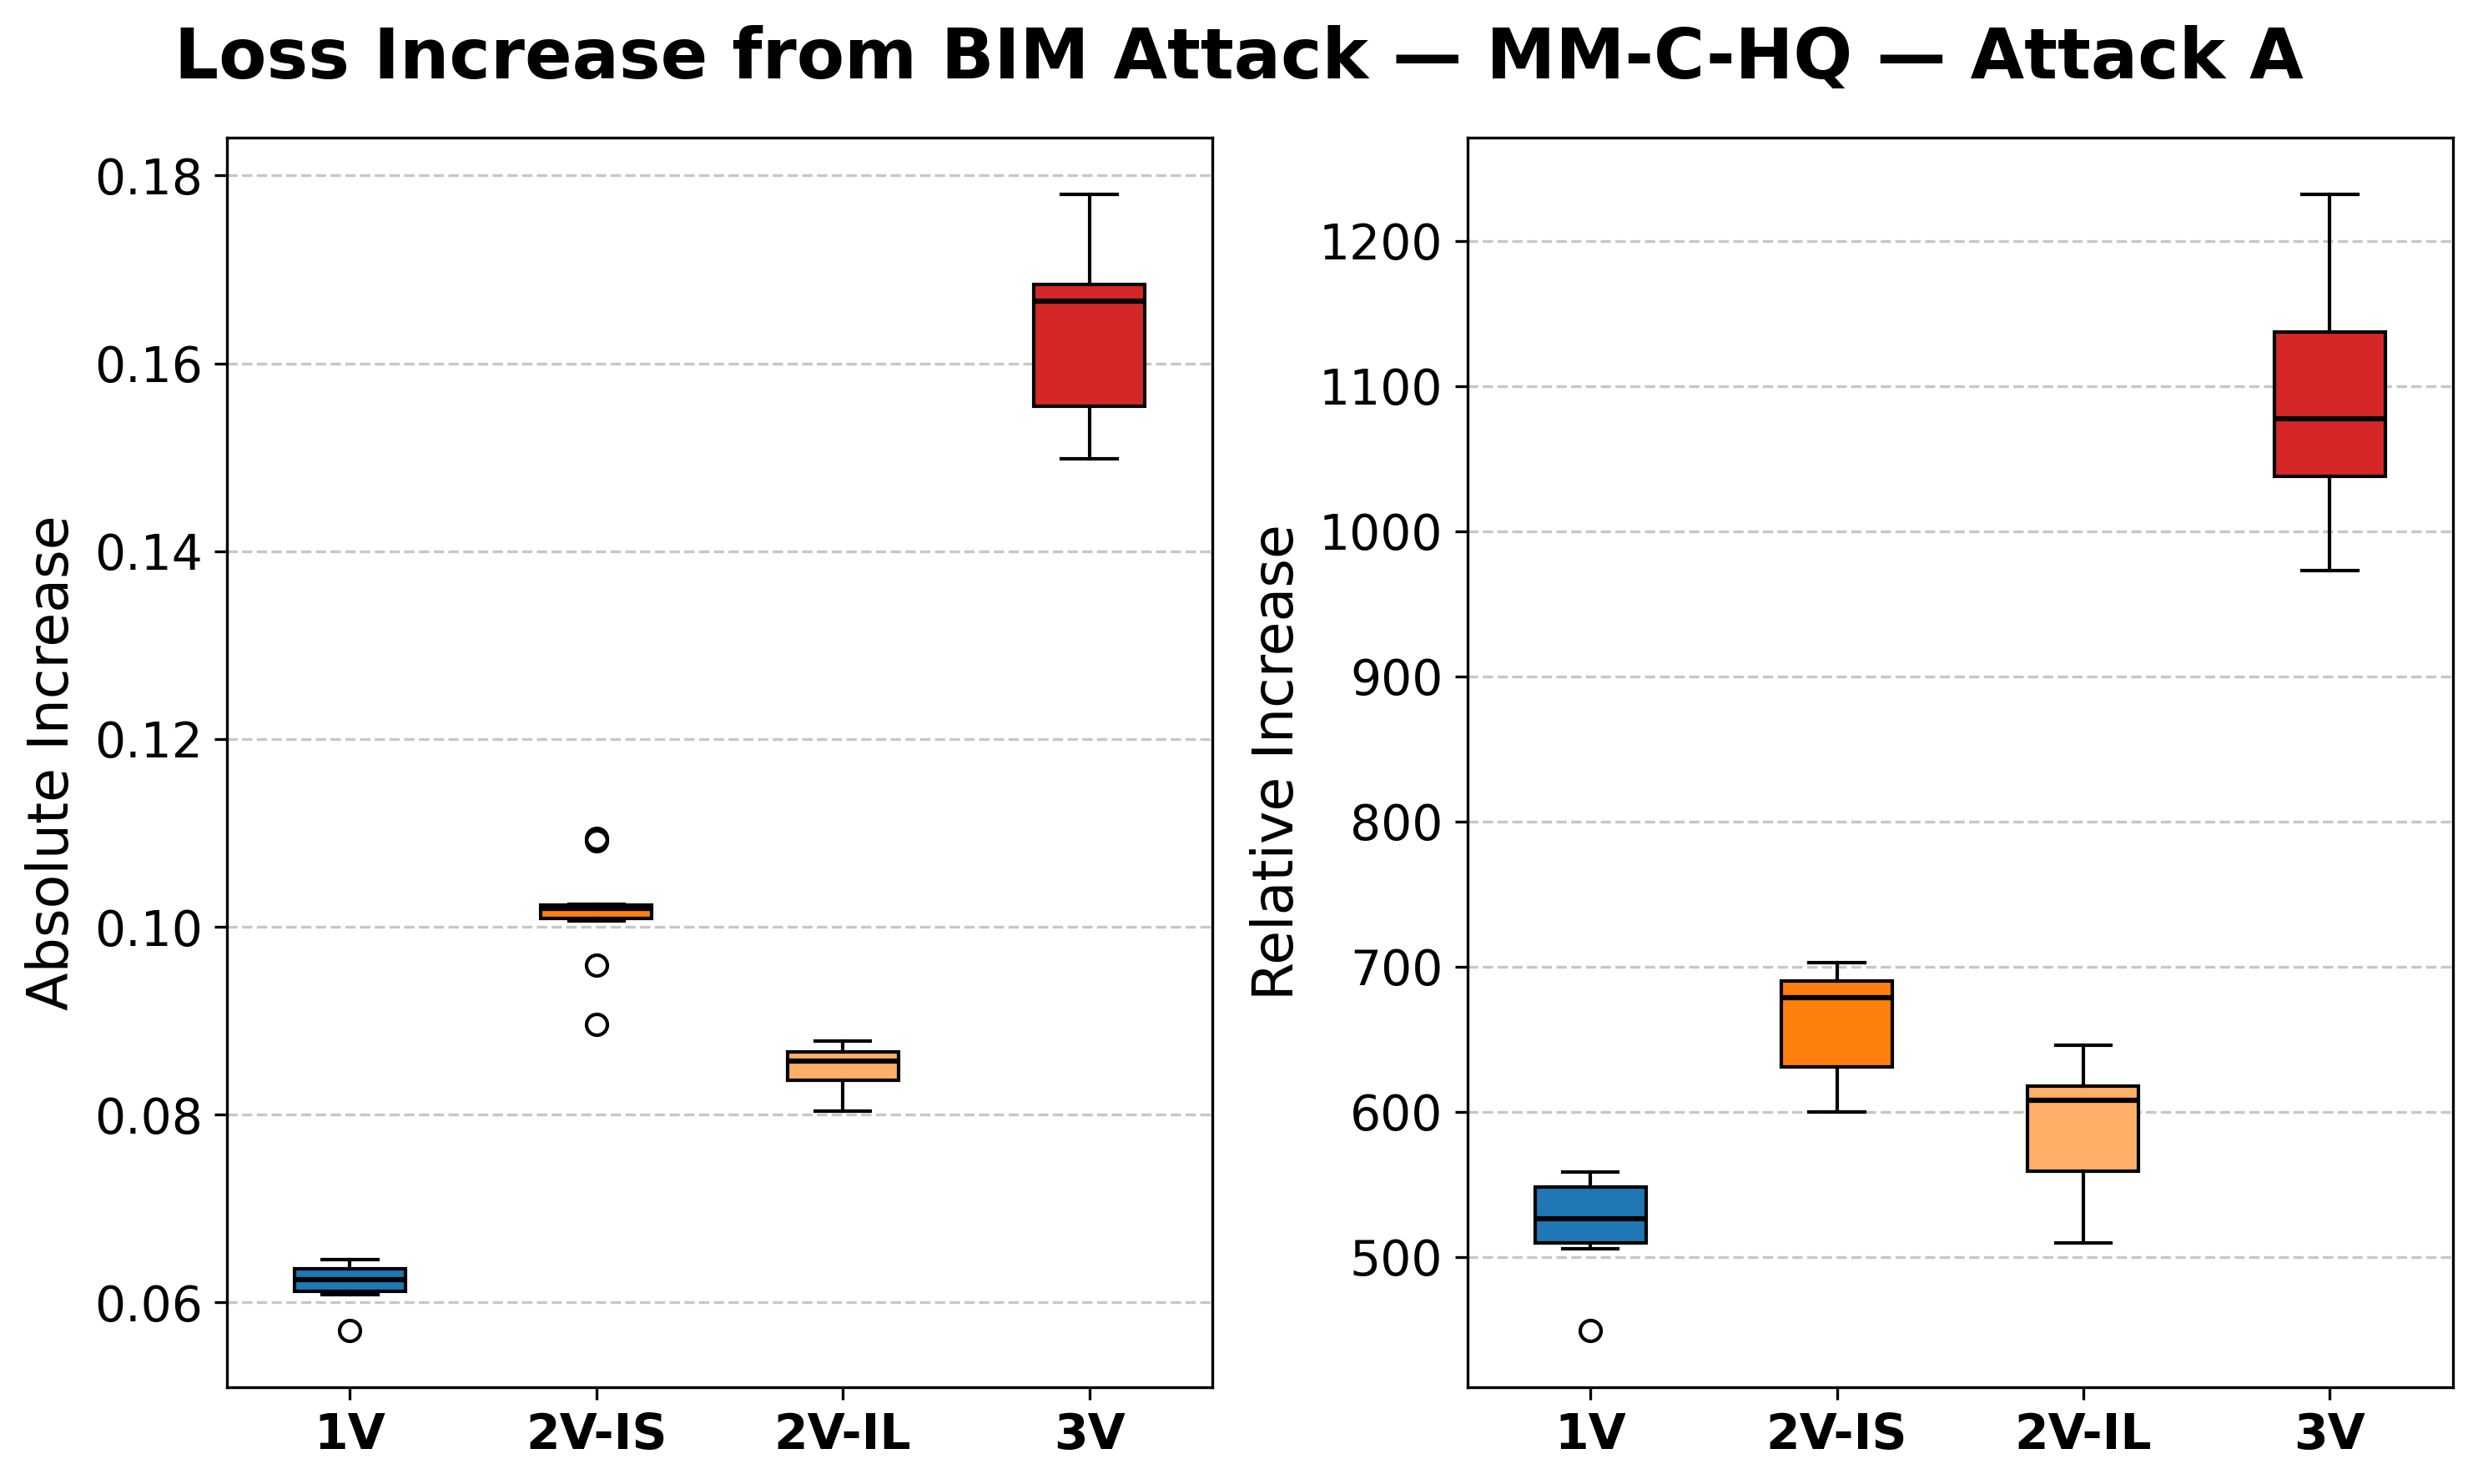

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=300)

plot_specs = [
    (
        'Absolute Increase',
        'Absolute Image Loss Increase',
        'BIM_IM_Abs_Increase',
    ),
    (
        'Relative Increase',
        'Relative Image Loss Increase (%)',
        'BIM_IM_Rel_Increase',
    ),
]

model_positions = np.arange(len(model_order))

for ax, (ylabel, title, col) in zip(axes, plot_specs):
    values = [
        df_test.loc[df_test['model'].eq(model), col].dropna().to_numpy()
        for model in model_order
    ]

    box = ax.boxplot(
        values,
        positions=model_positions,
        widths=0.45,
        patch_artist=True,
        showfliers=True,
    )

    for patch, model in zip(box['boxes'], model_order):
        patch.set_facecolor(model_color_map[model])
        patch.set_edgecolor('black')

    for median in box['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in box['whiskers']:
        whisker.set_color('black')

    for cap in box['caps']:
        cap.set_color('black')

    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xticks(model_positions)
    ax.set_xticklabels(model_order, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Loss Increase from BIM Attack — MM-C-HQ — Attack A', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/attack-A-image-loss-increases-boxplots.png', bbox_inches='tight')
plt.show()

## Statistical Tests - Attacks
### Normality

In [7]:
loss_cols = [
    'Clean_IM_Loss',
    'FGSM_IM_Loss',
    'BIM_IM_Loss',
]

In [8]:
normality_results = []

for col in loss_cols:
    values = df_test[col].dropna()

    stat, p_value = shapiro(values)

    normality_results.append({
        'column': col,
        'n': len(values),
        'W-statistic': stat,
        'p-value': p_value,
        'normal': p_value > 0.05,
    })

normality_df = pd.DataFrame(normality_results)

normality_df

,column,n,W-statistic,p-value,normal
0,Clean_IM_Loss,40,0.903259,0.002381,False
1,FGSM_IM_Loss,40,0.891613,0.001100,False
2,BIM_IM_Loss,40,0.862896,0.000188,False


### Significance

In [9]:
groups = [
    df_test[col].dropna().to_numpy()
    for col in loss_cols
]

h_stat, p_value = kruskal(*groups)

kruskal_results = pd.DataFrame({
    'test': ['Kruskal-Wallis'],
    'columns': [', '.join(loss_cols)],
    'H-statistic': [h_stat],
    'p-value': [p_value],
    'significant': [p_value < 0.05],
})

kruskal_results

,test,columns,H-statistic,p-value,significant
0,Kruskal-Wallis,"Clean_IM_Loss, FGSM_IM_Loss, BIM_IM_Loss",91.078058,1.669748e-20,True


In [10]:
df_long = (
    df_test[loss_cols]
    .melt(var_name='attack', value_name='loss')
    .dropna()
)

# Dunn post-hoc test
dunn_results = sp.posthoc_dunn(
    df_long,
    val_col='loss',
    group_col='attack',
    p_adjust='holm',
)

dunn_results

,BIM_IM_Loss,Clean_IM_Loss,FGSM_IM_Loss
BIM_IM_Loss,1.000000e+00,3.927794e-09,6.119683e-04
Clean_IM_Loss,3.927794e-09,1.000000e+00,1.265727e-20
FGSM_IM_Loss,6.119683e-04,1.265727e-20,1.000000e+00


## Statistical Tests - Multi-View
### Normality

In [11]:
test_cols = [
    'FGSM_IM_Loss',
    'FGSM_IM_Abs_Increase',
    'FGSM_IM_Rel_Increase',
    'BIM_IM_Loss',
    'BIM_IM_Abs_Increase',
    'BIM_IM_Rel_Increase',
]

In [ ]:
normality_results = []

for col in test_cols:
    print(f'\n===== {col} =====')

    for model in model_order:
        values = (
            df_test
            .loc[df_test['model'].eq(model), col]
            .dropna()
            .to_numpy()
        )

        w_stat, p_value = shapiro(values)

        normality_results.append({
            'metric': col,
            'model': model,
            'W': w_stat,
            'p': p_value,
            'normal': p_value > 0.05,
        })

        print(f'{model}: W = {w_stat:.4f}, p = {p_value:.4f}')

normality_df = pd.DataFrame(normality_results)
normality_df


===== FGSM_IM_Loss =====
1V: W = 0.9343, p = 0.4919
2V-IS: W = 0.9290, p = 0.4379
2V-IL: W = 0.9884, p = 0.9945
3V: W = 0.9262, p = 0.4114

===== FGSM_IM_Abs_Increase =====
1V: W = 0.9749, p = 0.9322
2V-IS: W = 0.9228, p = 0.3810
2V-IL: W = 0.9418, p = 0.5735
3V: W = 0.9219, p = 0.3733

===== FGSM_IM_Rel_Increase =====
1V: W = 0.9427, p = 0.5833
2V-IS: W = 0.8718, p = 0.1049
2V-IL: W = 0.9114, p = 0.2907
3V: W = 0.9551, p = 0.7287

===== BIM_IM_Loss =====
1V: W = 0.9543, p = 0.7196
2V-IS: W = 0.9018, p = 0.2291
2V-IL: W = 0.9488, p = 0.6542
3V: W = 0.8693, p = 0.0982

===== BIM_IM_Abs_Increase =====
1V: W = 0.8747, p = 0.1134
2V-IS: W = 0.8808, p = 0.1333
2V-IL: W = 0.9262, p = 0.4119
3V: W = 0.8806, p = 0.1326

===== BIM_IM_Rel_Increase =====
1V: W = 0.8864, p = 0.1545
2V-IS: W = 0.8620, p = 0.0807
2V-IL: W = 0.9262, p = 0.4114
3V: W = 0.9686, p = 0.8775


,metric,model,W,p,normal
0,FGSM_IM_Loss,1V,0.934335,0.491852,True
1,FGSM_IM_Loss,2V-IS,0.928973,0.437869,True
2,FGSM_IM_Loss,2V-IL,0.988420,0.994497,True
3,FGSM_IM_Loss,3V,0.926177,0.411361,True
4,FGSM_IM_Abs_Increase,1V,0.974901,0.932203,True
5,FGSM_IM_Abs_Increase,2V-IS,0.922815,0.381034,True
6,FGSM_IM_Abs_Increase,2V-IL,0.941828,0.573526,True
7,FGSM_IM_Abs_Increase,3V,0.921921,0.373254,True
8,FGSM_IM_Rel_Increase,1V,0.942691,0.583328,True
9,FGSM_IM_Rel_Increase,2V-IS,0.871791,0.104883,True


### Significance

In [13]:
anova_results = []

for col in test_cols:
    groups = [
        df_test
        .loc[df_test['model'].eq(model), col]
        .dropna()
        .to_numpy()
        for model in model_order
    ]

    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        'metric': col,
        'F': f_stat,
        'p': p_value,
        'significant': p_value < 0.05,
    })

    print(f'\n===== {col} =====')
    print(f'F-statistic: {f_stat:.6f}')
    print(f'p-value: {p_value:.6e}')

anova_df = pd.DataFrame(anova_results)
anova_df


===== FGSM_IM_Loss =====
F-statistic: 435.416319
p-value: 2.487916e-28

===== FGSM_IM_Abs_Increase =====
F-statistic: 415.818140
p-value: 5.568311e-28

===== FGSM_IM_Rel_Increase =====
F-statistic: 113.226858
p-value: 2.162794e-18

===== BIM_IM_Loss =====
F-statistic: 580.592737
p-value: 1.586417e-30

===== BIM_IM_Abs_Increase =====
F-statistic: 552.236501
p-value: 3.832801e-30

===== BIM_IM_Rel_Increase =====
F-statistic: 233.743087
p-value: 1.189291e-23


,metric,F,p,significant
0,FGSM_IM_Loss,435.416319,2.487916e-28,True
1,FGSM_IM_Abs_Increase,415.818140,5.568311e-28,True
2,FGSM_IM_Rel_Increase,113.226858,2.162794e-18,True
3,BIM_IM_Loss,580.592737,1.586417e-30,True
4,BIM_IM_Abs_Increase,552.236501,3.832801e-30,True
5,BIM_IM_Rel_Increase,233.743087,1.189291e-23,True


### Tukey post-hoc

In [14]:

def tukey_letter_display(data, value_col, group_col='model', group_order=None, alpha=0.05):
    if group_order is None:
        group_order = sorted(data[group_col].dropna().unique())

    tukey = pairwise_tukeyhsd(
        endog=data[value_col],
        groups=data[group_col],
        alpha=alpha,
    )

    tukey_df = pd.DataFrame(
        tukey._results_table.data[1:],
        columns=tukey._results_table.data[0],
    )

    reject_df = pd.DataFrame(
        False,
        index=group_order,
        columns=group_order,
    )

    for _, row in tukey_df.iterrows():
        g1 = row['group1']
        g2 = row['group2']
        reject = bool(row['reject'])

        reject_df.loc[g1, g2] = reject
        reject_df.loc[g2, g1] = reject

    means = (
        data
        .groupby(group_col)[value_col]
        .mean()
        .loc[group_order]
        .sort_values()
    )

    letters = {group: '' for group in means.index}
    available_letters = list(string.ascii_lowercase)

    for group in means.index:
        for letter in available_letters:
            groups_with_letter = [
                other_group
                for other_group, assigned_letters in letters.items()
                if letter in assigned_letters
            ]

            can_share_letter = all(
                not reject_df.loc[group, other_group]
                for other_group in groups_with_letter
            )

            if can_share_letter:
                letters[group] += letter
                break

        if letters[group] == '':
            new_letter = available_letters[
                max(
                    [available_letters.index(l) for ls in letters.values() for l in ls],
                    default=-1,
                ) + 1
            ]
            letters[group] += new_letter

    letter_df = pd.DataFrame({
        group_col: group_order,
        'mean': data.groupby(group_col)[value_col].mean().loc[group_order].values,
        'letters': [letters[group] for group in group_order],
    })

    return tukey, tukey_df, letter_df

In [15]:
for col in test_cols:
    print(f'\n===== {col} =====')

    tukey, tukey_df, letter_df = tukey_letter_display(
        df_test,
        value_col=col,
        group_col='model',
        group_order=model_order,
        alpha=0.05,
    )
    
    display(letter_df)


===== FGSM_IM_Loss =====


,model,mean,letters
0,1V,0.126959,a
1,2V-IS,0.177589,c
2,2V-IL,0.158771,b
3,3V,0.237792,d



===== FGSM_IM_Abs_Increase =====


,model,mean,letters
0,1V,0.115073,a
1,2V-IS,0.162246,c
2,2V-IL,0.144371,b
3,3V,0.222624,d



===== FGSM_IM_Rel_Increase =====


...

,model,mean,letters
0,1V,0.073915,a
1,2V-IS,0.116841,c
2,2V-IL,0.099359,b
3,3V,0.179204,d



===== BIM_IM_Abs_Increase =====


,model,mean,letters
0,1V,0.062028,a
1,2V-IS,0.101498,c
2,2V-IL,0.084960,b
3,3V,0.164035,d



===== BIM_IM_Rel_Increase =====


,model,mean,letters
0,1V,522.775621,a
1,2V-IS,662.044684,c
2,2V-IL,592.038773,b
3,3V,1083.228795,d
